In [93]:
import cv2
import matplotlib.image as im
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog 

### Reading images

In [44]:
#Using open-cv
img = cv2.imread('lane.jpg')
#Color format(BGR)

#Using matplotlib
img_mpt = im.imread('lane.jpg')
#Color format(RGB)

### Displaying Image

In [46]:
#cv2 image
cv2.imshow("Lane Image",img)

#Waiting until any key is pressed
cv2.waitKey()

#Closing window
cv2.destroyAllWindows()

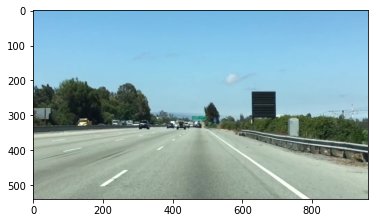

In [50]:
#mpt image
plt.imshow(img_mpt)

### Converting color image to gray scale

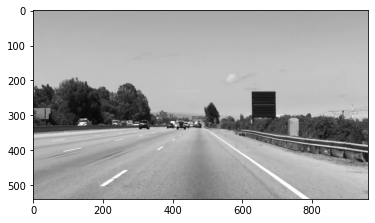

In [48]:
gray_image = cv2.cvtColor(img_mpt,cv2.COLOR_RGB2GRAY)
plt.imshow(gray_image,cmap='gray')

### Identifying the lane lines in gray-scale image
1. Taking out white pixels

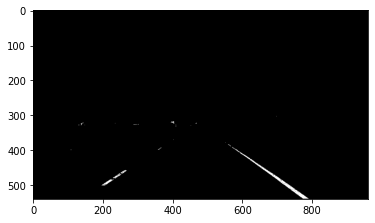

In [39]:
img_gray = np.copy(gray_image)

#Setting pixes which are not white to zeros
img_gray[(img_gray[:,:] < 250)] = 0

plt.imshow(img_gray,cmap='gray')

### Identifying the lane lines in colored image

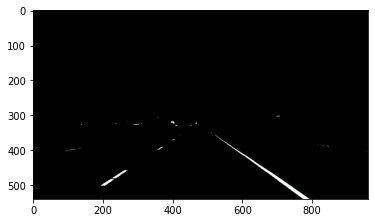

In [43]:
img_color = np.copy(img)
img_color[(img_color[:,:,0] < 230) | (img_color[:,:,1] < 230) | (img_color[:,:,2] < 230)] = 0
plt.imshow(img_color)

### COLOR spaces
1. RGB
2. HSV (Hue, Saturation, Value)

(540, 960, 3)

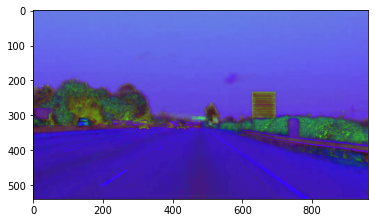

In [62]:
#### Converting RGB to HUE
hsv_img = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
plt.imshow(hsv_img)
hsv_img.shape

In [74]:
#cv2 image
cv2.imshow("HSV Image",hsv_img)

#Waiting until any key is pressed
cv2.waitKey()

#Closing window
cv2.destroyAllWindows()

In [75]:
img.shape

(540, 960, 3)

### Splitting RGB channels

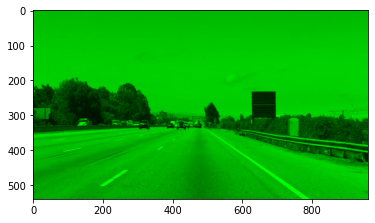

In [89]:
B,G,R = cv2.split(img)

#Creating empty green and red channels
empty_channel = np.zeros(img.shape[:2],dtype='uint8')

Blue_channel = cv2.merge([empty_channel,empty_channel,B])
Red_channel = cv2.merge([R,empty_channel,empty_channel])
Green_channel = cv2.merge([empty_channel,G,empty_channel])

plt.imshow(Green_channel)

### Merging color channels

In [99]:
img_merged = cv2.merge([R,G,B])

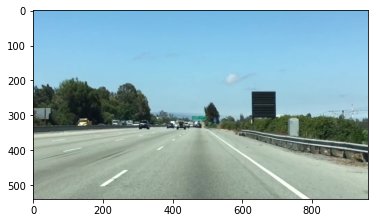

In [100]:
plt.imshow(img_merged)

### Convolution
Select a feature detector or kernel then move over the gray scale image and perform convolution and stride 

#### Sharpening

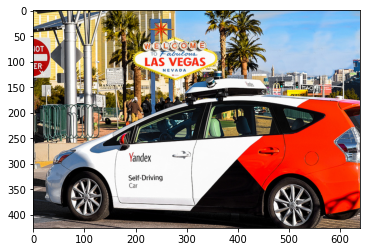

In [120]:
img_car = cv2.imread('car.jpg')
plt.imshow(cv2.cvtColor(img_car, cv2.COLOR_BGR2RGB))

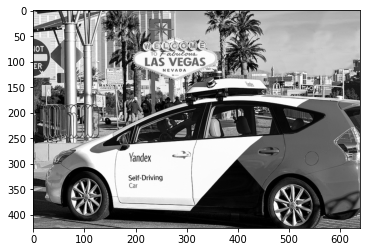

In [121]:
img_gray_car = cv2.cvtColor(img_car,cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray_car,cmap='gray')

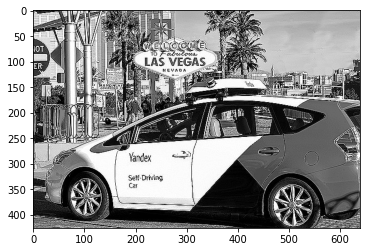

In [122]:
sharpe_kernel = np.array([[0,-1,0],
                        [-1,5,-1],
                        [0,-1,0]])
sharpened_img = cv2.filter2D(img_gray_car,-1,sharpe_kernel)
plt.imshow(sharpened_img,cmap='gray')

#### Blurring

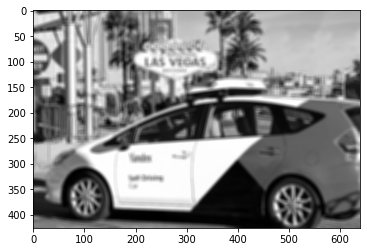

In [131]:
blur_kernel = np.ones((8,8),dtype='uint8')/64
blured_img = cv2.filter2D(img_gray_car,-1,blur_kernel)
plt.imshow(blured_img,cmap='gray')

### Edge detection
1. Sobel
2. Laplacian
3. Canny

#### Sobel Edge Detection

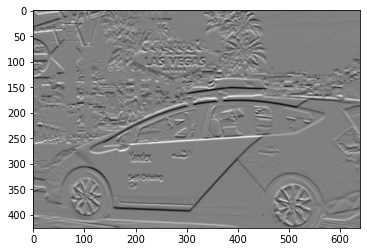

In [134]:
x_sobel = cv2.Sobel(img_gray_car,cv2.CV_64F,0,1,ksize=7)
plt.imshow(x_sobel,cmap='gray')

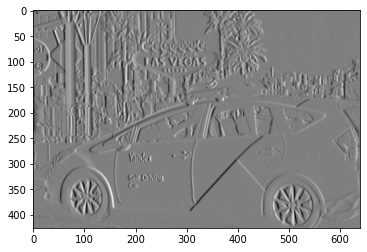

In [135]:
y_sobel = cv2.Sobel(img_gray_car,cv2.CV_64F,1,0,ksize=7)
plt.imshow(y_sobel,cmap='gray')

#### Laplacian Edge Detection

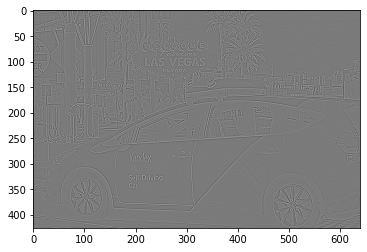

In [140]:
laplacian = cv2.Laplacian(img_gray_car,cv2.CV_64F)
plt.imshow(laplacian,cmap='gray')

### Canny Edge Detection

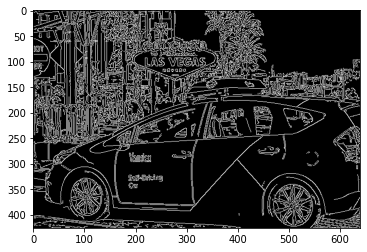

In [146]:
threshold_1 = 120
threshold_2 = 200

canny = cv2.Canny(img_gray_car,threshold_1,threshold_2)
plt.imshow(canny,cmap='gray')


### Image transformation

In [1]:
# Used to correct the distorsion and change perpectives
# Affine transformation preserve parallelism
# Projective (Non Affine) transformation does not preserve parallelism, length and angle

In [2]:
# Affine Transformation
#  #     #    #
#  #    #    #

In [3]:
#Non Affine
# #    #  #
# #   #    #

#### Rotation

Rotations by rotation matrix in Euclidian space\
Rotates counter clock wise by an angle theta about the origin

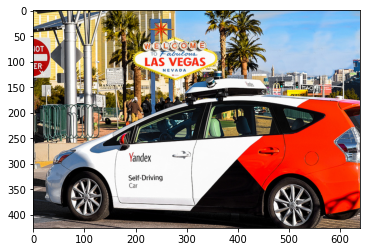

In [3]:
img_car = cv2.imread('car.jpg')
plt.imshow(cv2.cvtColor(img_car, cv2.COLOR_BGR2RGB))

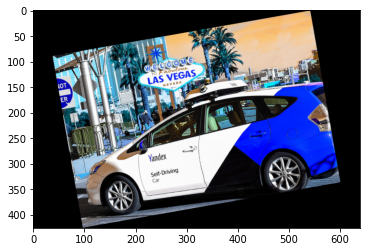

In [20]:
width = img_car.shape[1]
height = img_car.shape[0]
center = (width/2,height/2)
angle = 10
scale = 0.8
rotation_mat = cv2.getRotationMatrix2D(center,angle,scale)
rotated_img = cv2.warpAffine(img_car,rotation_mat,(width,height))
plt.imshow(rotated_img)

In [25]:
rotation_mat

array([[ 0.7878462 ,  0.13891854, 38.29956575],
       [-0.13891854,  0.7878462 , 89.64269237]])

### Translation


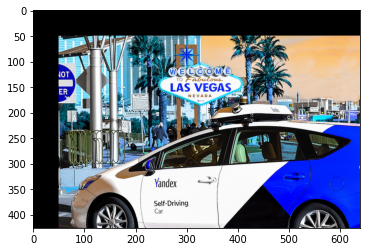

In [26]:

translation_mat = np.array([[1,0,50],[0,1,50]]).astype(np.float32)
translated_img = cv2.warpAffine(img_car,translation_mat,(width,height))
plt.imshow(translated_img)

### Resizing 
Interpolation methods : \
    INTER_AREA for shrinking\
    INTER_CUBIC for zooming
    

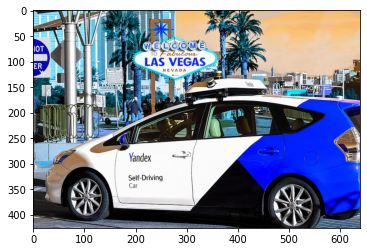

In [9]:
img_car = cv2.imread('car.jpg')

resized_image = cv2.resize(img_car,None,fx=1,fy=1,interpolation = cv2.INTER_CUBIC)
plt.imshow(resized_image)

### Perspective Transformation
Correct distorsion\
Does not preserve length,parallelism and angle\
Projective (Non affine)

Steps :

1. Identify source points
2. Destination Points
3. Create mat
4. Apply transformation


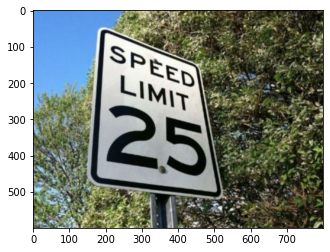

In [16]:
speed_sign_distorted = cv2.imread('speed_sign.jpg')
img = im.imread('speed_sign.jpg')
plt.imshow(img)


In [25]:

#First : top-left
#Second : top-right
#Third : bottom-right
#Fourth : bottom-left
height,width = speed_sign_distorted.shape[:2]
source_points = np.array([[190,50],[450,150],[520,520],[150,480]]).astype(np.float32)
destination_points = np.array([[0,0],[width,0],[width,height],[0,height]]).astype(np.float32)

In [26]:
corrector_mat = cv2.getPerspectiveTransform(source_points,destination_points)
corrector_mat

array([[ 2.16363132e+00,  2.01268030e-01, -4.21153352e+02],
       [-6.79871897e-01,  1.76766693e+00,  4.07923138e+01],
       [-9.15867424e-04,  9.36526821e-04,  1.00000000e+00]])

In [31]:
correct_img = cv2.warpPerspective(speed_sign_distorted,corrector_mat,(width,height))

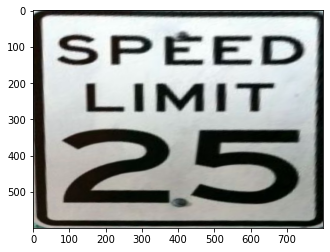

In [32]:
plt.imshow(correct_img)

### Dilation and Erosion

Dilation : Adding pixels to the boundaries of objects in an image\
Erosion : Removing pixels to the boundaries of objects in an image

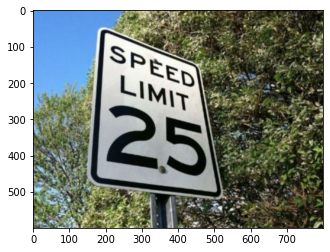

In [6]:
img = cv2.imread('speed_sign.jpg')
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))



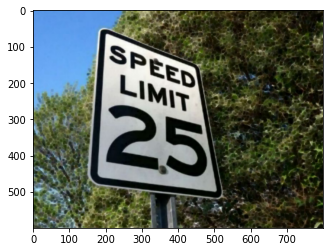

In [19]:
#Erosion
kernel = np.ones((4,4),np.uint8)
img_erosion = cv2.erode(img,kernel,iterations=1)
plt.imshow(cv2.cvtColor(img_erosion,cv2.COLOR_BGR2RGB))

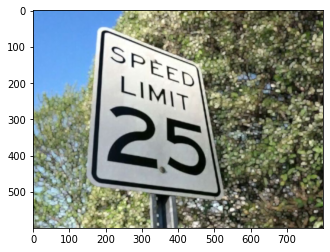

In [17]:
#Dilation
kernel = np.ones((4,4),np.uint8)
img_dilate = cv2.dilate(img,kernel,iterations=1)
plt.imshow(cv2.cvtColor(img_dilate,cv2.COLOR_BGR2RGB))

### Region of interest masking

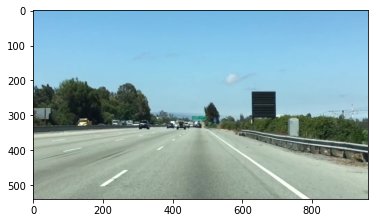

In [20]:
img = cv2.imread('lane.jpg')
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))


In [29]:
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
## Mask creation
height,width = img.shape[:2]
ROI = np.array([[(0,height),(360,340),(480,340),(800,height)]],dtype=np.int32)
blank = np.zeros_like(img_gray)
mask = cv2.fillPoly(blank,ROI,255)

masked_img = cv2.bitwise_and(img_gray,mask)

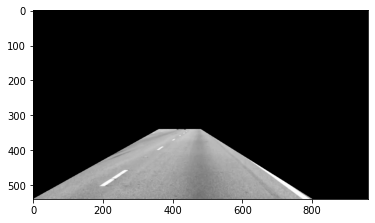

In [31]:
plt.imshow(masked_img,cmap='gray')

### Detecting Lane lines
#### Hough Transform

$x\cos{\theta} + y\sin{\theta} = \rho$\
$y = -x*cot(\theta) + \rho*cosec(theta)$

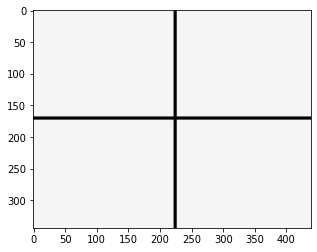

In [142]:
img = cv2.imread('horizontal_vertical.jpg')
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

In [143]:
def detect_lines(img):
    img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    img_blur=cv2.GaussianBlur(img_gray,(7,7),0)
    img_canny = cv2.Canny(img_blur,50,200,apertureSize=3)
    plt.imshow(img_canny,cmap='gray')
    plt.show()
    
    rho_acc = 1
    theta_acc = np.pi/180
    thresh = 300
    lines = cv2.HoughLines(img_canny,rho_acc,theta_acc,thresh)
    return lines

In [144]:
def draw_line(img,lines):
    try:
        lines = lines.reshape(-1,2)
        for line in lines:
            rho = line[0]
            theta = line[1]
            x0 = rho*np.cos(theta) 
            y0 = rho*np.sin(theta)
            a = np.cos(theta)
            b = np.sin(theta)

            x1 = int(x0 + 1000*(-b))
            x2 = int(x0 - 1000*(-b))
            y1 = int(y0 + 1000*a)
            y2 = int(y0 - 1000*a)

            cv2.line(img,(x1,y1),(x2,y2),(0,255,0),4)
    except AttributeError as e:
        print("No line found!")

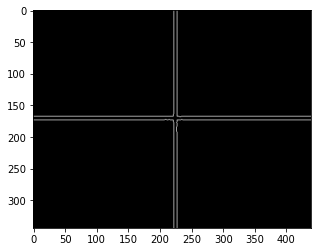

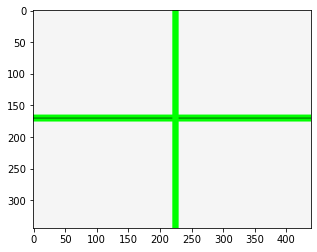

In [145]:
lines = detect_lines(img)
draw_line(img,lines)
plt.imshow(img)
plt.show()

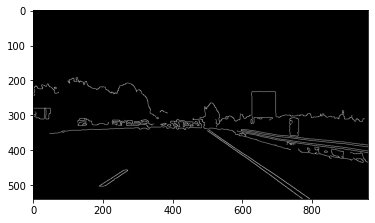

No line found!


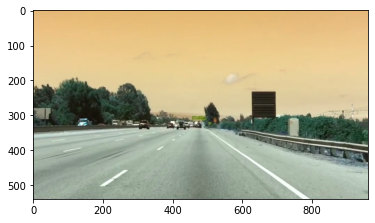

In [146]:
img = cv2.imread('lane.jpg')
lines = detect_lines(img)
draw_line(img,lines)
plt.imshow(img)
plt.show()

In [198]:
def detect_lane_lines(img):
    img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    img_blur=cv2.GaussianBlur(img_gray,(7,7),2)
    img_canny = cv2.Canny(img_blur,10,200,apertureSize=3)
    height,width = img_canny.shape[:2]
    ROI = np.array([[(20,460),(340,300),(460,300),(740,460)]],dtype=np.int32)
    blank = np.zeros_like(img_canny)
    mask = cv2.fillPoly(blank,ROI,255)
    masked_img = cv2.bitwise_and(img_canny,mask)
    plt.imshow(masked_img)
    plt.show()
    
    rho_acc = 2
    theta_acc = np.pi/180
    thresh = 40
    min_line_length = 120
    max_line_gap = 50
    lines = cv2.HoughLinesP(masked_img,rho_acc,theta_acc,thresh,np.array([]),minLineLength=min_line_length,
                           maxLineGap=max_line_gap)
    img = np.zeros_like(img)
    try:
        for line in lines:
            for x1,y1,x2,y2 in line:
                cv2.line(img,(x1,y1),(x2,y2),(0,255,0),9)
    except Exception as e:
        print(e)
        print("No line found!")
    return img 


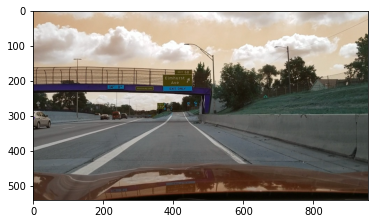

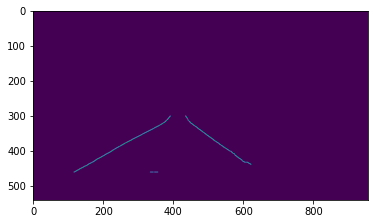

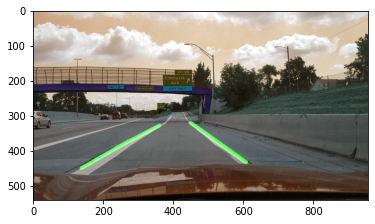

In [199]:
img_2 = cv2.imread('lane_2.jpg')
plt.imshow(img_2)
plt.show()
img_line = detect_lane_lines(img_2)
img_with_line = cv2.addWeighted(img_2,1,img_line,1,0)
plt.imshow(img_with_line)

### Features and Object Detection

### Template Matching

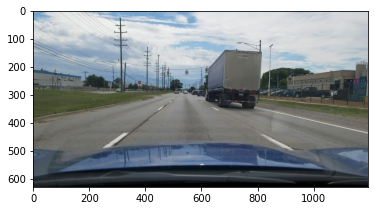

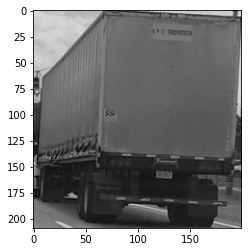

In [46]:
img = cv2.imread("lane_truck.jpg")
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.show()
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
template = cv2.imread("Truck_template.jpg",0)
plt.imshow(cv2.cvtColor(template,cv2.COLOR_BGR2RGB))
plt.show()
height,width = img.shape[:2]

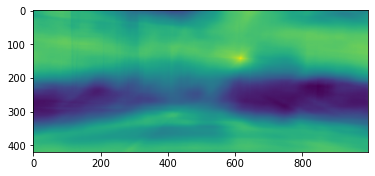

In [47]:
result = cv2.matchTemplate(img_gray,template,cv2.TM_CCOEFF_NORMED)
plt.imshow(result)

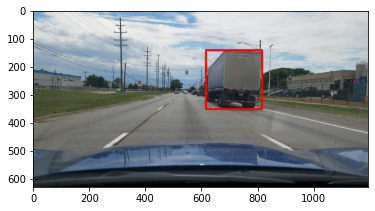

In [48]:
#Finding the indices of the object 
min_val,max_val,min_loc,max_loc = cv2.minMaxLoc(result)

top_left = max_loc
bottom_right = (max_loc[0]+template.shape[1],max_loc[1]+template.shape[0])
#Drawing the rectangle around the object
cv2.rectangle(img,top_left,bottom_right,(0,0,255),5)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

### Corner Detection

### Haris corner Detection

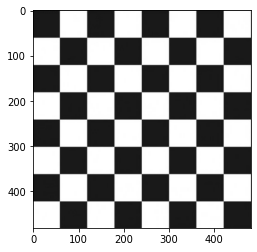

In [57]:
img_ = cv2.imread("chessboard.jpg")
plt.imshow(img_,cmap='gray')
plt.show()

In [58]:
def getCorners(img):
    img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    
    corners = cv2.cornerHarris(img_gray,5,3,0.1)
    plt.imshow(corners,cmap='gray')

    #Adding pixels at the corners
    corners_dilate = cv2.dilate(corners,np.ones((8,8),dtype=np.uint8),iterations=1)
    plt.imshow(corners_dilate,cmap='gray')
    
    #Replacing corner white pixels with green 
    img[corners_dilate > 0.01*corners_dilate.max()] = [0,255,0]
    
    plt.imshow(img)

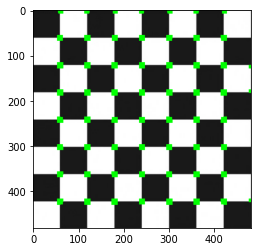

In [60]:
getCorners(img_)

### Image Scaling/Pyramiding

Used for template matching by finding the object at different scales\
Gaussian Pyramiding is the common used method\
Gaussian Pyramiding Step
   1. Convolve the image with Gaussian Kernal
   2. Remove every even-numbered row and column
    

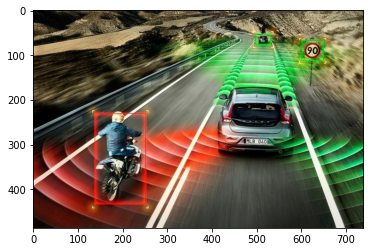

In [63]:
img = cv2.imread('Self_Driving.jpg')
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

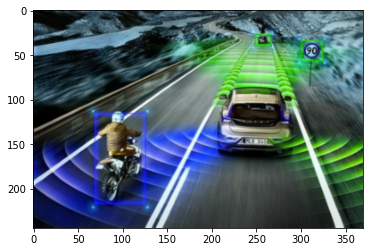

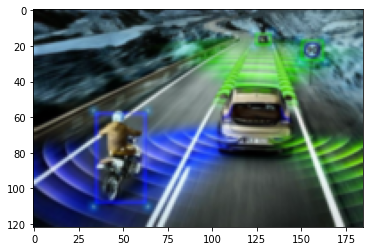

In [72]:
scaled_down1 = cv2.pyrDown(img)
plt.imshow(scaled_down1)
plt.show()
scaled_down2 = cv2.pyrDown(scaled_down1)
plt.imshow(scaled_down2)
plt.show()

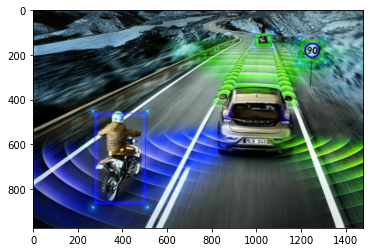

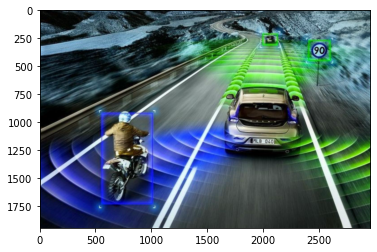

In [73]:
scaled_up1 = cv2.pyrUp(img)
plt.imshow(scaled_up1)
plt.show()
scaled_up2 = cv2.pyrUp(scaled_up1)
plt.imshow(scaled_up2)
plt.show()

### Histogram of color

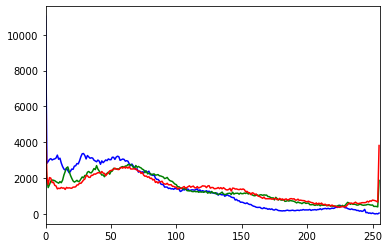

In [86]:
colors = ('b','g','r')
mask = None
hist_size = [256]
ranges = [0,256]

for i,color in enumerate(colors):
    hists = cv2.calcHist([img],[i],mask,hist_size,ranges)
    plt.plot(hists,color=color)
    plt.xlim([0,256])


### Histogram Oriented Gradient(HOG)

* For a function f(x,y), the gradient is the vector (fx,fy)
* At each pixel, the horizontal and vertical gradients are calculated
* The direction is atan(fy/fx) and magnitude sqrt(fx^2 + fy^2)
* The pixels are mapped to 0-255
* The pixels with large -ve => black
* The pixels with large +ve => white
* The pixels with little or no change will be gray

Steps :
1. Using 8*8 pixel cell, calculate gradient map/direction
2. 
   * Create a histogram generated 64(8*8) gradient vectors
   * Each cell is then split into angular bins, each bin corresponds to a gradient direction (9 bins 0-180deg) (20deg each bin)
   * This reduces 64 vectors to just 9 values

In [89]:
truck = cv2.imread('truck1.jpg')

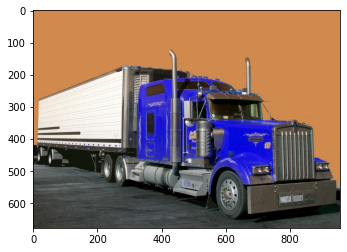

In [90]:
plt.imshow(truck)

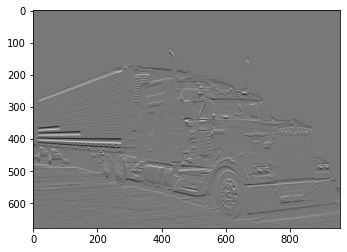

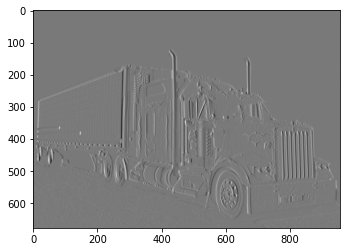

In [104]:
truck_gray = cv2.cvtColor(truck,cv2.COLOR_BGR2GRAY)
sobel_x = cv2.Sobel(truck_gray,cv2.CV_64FC1,0,1,ksize=7)
plt.imshow(sobel_x,cmap='gray')
plt.show()
sobel_y = cv2.Sobel(truck_gray,cv2.CV_64FC1,1,0,ksize=7)
plt.imshow(sobel_y,cmap='gray')
plt.show()

In [105]:
features,hog_img = hog(truck_gray,
                       orientations=9,
                       pixels_per_cell=(16,16),
                       transform_sqrt=True,
                       visualize=True,
                       feature_vector=False
                      )

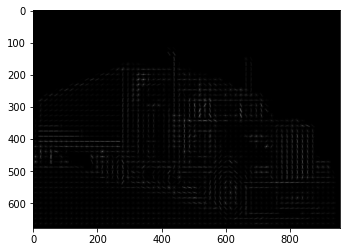

In [106]:
plt.imshow(hog_img,cmap='gray')

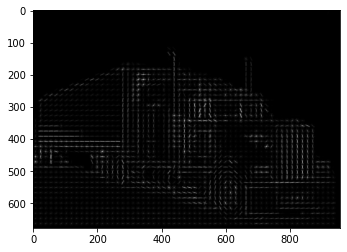

In [107]:
from skimage import exposure
#Increasing intensity
hog_img_rescaled = exposure.rescale_intensity(hog_img,in_range=(0,2))

plt.imshow(hog_img_rescaled,cmap='gray')                       

### Feature Extraction

### FAST,SIFT,ORB,SURF

## FAST (Feature from Accelerated Segment Test)
1. Select a pixel p in the image which is to be identified as an interest point
2. Get its intensity Ip
3. Select appropriate threshold value
4. Consider a circle of 16pixels around the pixel under test
5. Pixel p is a corner if there exists a set of contigous pixels in the cicle which is are all brighter 
than Ip+t or all darker than Ip-t.
6. A high speed test that only four pixels at 1,9,5,13. If p is a corner, then at least three of these must be brighter
than Ip+t or darker than Ip-t. If neither of these is the case , the p can not be a corner

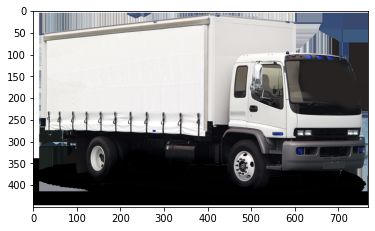

In [112]:
img = cv2.imread('truck2.png')
plt.imshow(img)

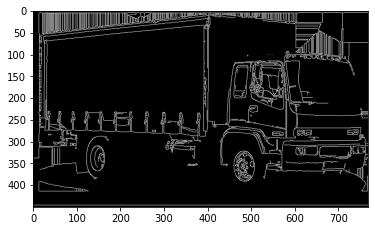

In [120]:
height, width = img.shape[:2]
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

thresh1 = 20
thresh2 = 250

img_canny = cv2.Canny(img_gray,thresh1,thresh2)
plt.imshow(img_canny,cmap='gray')

### Creating feature detector using FAST

In [127]:
#Creating feature detector
fast = cv2.FastFeatureDetector_create()
keypoints = fast.detect(img_gray,None)
print('No. of keypopints detected : {}'.format(len(keypoints)))

No. of keypopints detected : 2371


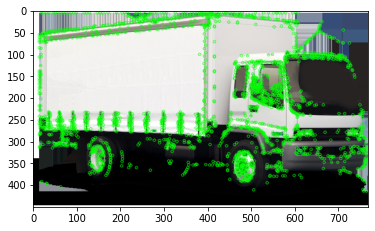

In [128]:
image = cv2.drawKeypoints(img,keypoints,None,color=(0,255,0))
plt.imshow(image)

### Creating feature detector using ORB

No. of keypopints detected : 500


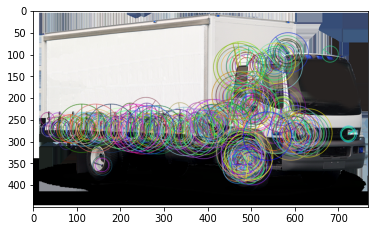

In [135]:
orb = cv2.ORB_create()
keypoints = orb.detect(img_gray,None)

keypoints,descriptors = orb.compute(img_gray,keypoints)
print('No. of keypopints detected : {}'.format(len(keypoints)))

image = cv2.drawKeypoints(img,keypoints,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(image)